# EnMAP NO2 retrieval testing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import rasterio
from rasterio.transform import Affine
from scipy import linalg
from lxml import etree
from scipy.ndimage import gaussian_filter

In [4]:
wav_min = 418
wav_max = 492
bin_size = 5
polydeg = 3

### Read EnMAP spectral band positions and widths from table

In [5]:
def read_enmap_spectral_bands_from_table(path, sheet=0):
    """
    Read an Excel/CSV table with at least 'CW (nm)' or 'wavelength' and 'FWHM (nm)' or 'fwhm' columns.
    """
    if path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path, sheet_name=sheet)
    else:
        df = pd.read_csv(path)
    # Normalize column names
    cols = {c.lower().strip(): c for c in df.columns}
    wcol = cols.get('cw (nm)', cols.get('wavelength', None))
    fcol = cols.get('fwhm (nm)', cols.get('fwhm', None))
    if wcol is None or fcol is None:
        raise ValueError("Spectral table must have 'CW (nm)'/'wavelength' and 'FWHM (nm)'/'fwhm' columns.")
    out = pd.DataFrame({
        'band': np.arange(1, len(df)+1),
        'wavelength_nm': df[wcol].astype(float).values,
        'fwhm_nm': df[fcol].astype(float).values
    }).sort_values('wavelength_nm').reset_index(drop=True)
    return out

In [6]:
enmap_vnir_spectral_bands = read_enmap_spectral_bands_from_table("EnMAP_Spectral_Bands_update.xlsx", sheet=0)
enmap_vnir_spectral_bands.head()

,band,wavelength_nm,fwhm_nm
0,1,418.416,6.99561
1,2,424.043,6.66750
2,3,429.457,6.42408
3,4,434.686,6.25124
4,5,439.758,6.13485


### Read Vandaele 220K NO2 absorption cross-sections

In [7]:
# Get NO2 absorption cross-sections @ 220K from Vandaele et al. (1998)
# Following TROPOMI NO2 ATBD: https://sentinel.esa.int/documents/247904/2476257/sentinel-5p-tropomi-atbd-no2-data-products
# Data reference: http://spectrolab.aeronomie.be/no2.htm
no2_cross_sections_path = "./cross_sections/no2c_97.txt"
no2_cross_sections = pd.read_csv(
    no2_cross_sections_path,
    sep=" ",
    usecols=[3, 4],
    names=["vacuum_wavenumber_cm-1", "cross_section_cm^2/molecule_@220K"],
)
# add wavelength column (nm)
no2_cross_sections["vacuum_wavelength_nm"] = 1e7 / no2_cross_sections["vacuum_wavenumber_cm-1"].values
no2_cross_sections.head()

,vacuum_wavenumber_cm-1,cross_section_cm^2/molecule_@220K,vacuum_wavelength_nm
0,14997.85211,8.133940e-21,666.762142
1,14998.81641,7.931970e-21,666.719275
2,14999.78071,7.087050e-21,666.676413
3,15000.74501,6.997210e-21,666.633557
4,15001.70931,7.817700e-21,666.590706


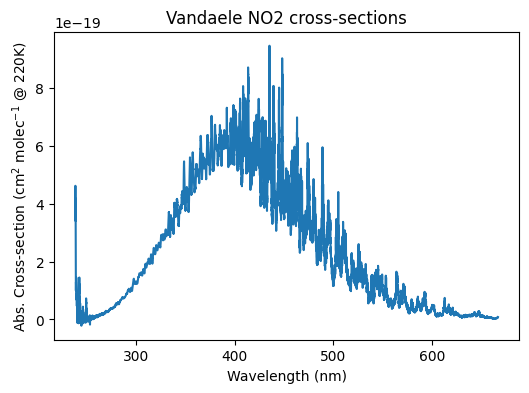

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(no2_cross_sections["vacuum_wavelength_nm"], no2_cross_sections["cross_section_cm^2/molecule_@220K"])
ax.set_title("Vandaele NO2 cross-sections")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Abs. Cross-section (cm$^2$ molec$^{-1}$ @ 220K)");

### Convolve cross-sections to EnMAP spectral grid using Gaussian SRF

In [9]:
def gaussian_kernel(x, mu, fwhm_nm):
    """
    Create normalized Gaussian kernel with standard deviation sigma (nm) based on sigma = FWHM/sqrt(2log2)
    """
    # Define standard deviation sigma
    sigma = fwhm_nm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    # Create kernel
    k = np.exp(-0.5 * ((x - mu) / sigma)**2)
    # Normalize kernel to area = 1
    k /= np.trapz(k, x, dx=0.01)
    return k

def convolve_to_sensor_grid(xs_wav_nm, xs, sensor_wav_nm, sensor_fwhm_nm):
    """
    Convolve high-res cross-section xs_sigma(xs_wav_nm) to sensor grid using per-band Gaussian SRF.
    Returns array of length len(sensor_wav_nm).
    """
    out = np.zeros_like(sensor_wav_nm, dtype=float)
    for i, (mu, fwhm) in enumerate(zip(sensor_wav_nm, sensor_fwhm_nm)):
        # Create normalized Gaussian kernel
        k = gaussian_kernel(xs_wav_nm, mu, fwhm)
        # Apply kernel to absorption cross-section spectrum
        out[i] = np.trapz(k * xs, xs_wav_nm, dx=0.01)
    return out

In [10]:
# Convolve cross-sections with Gaussian SRF
no2_cross_sections_conv = convolve_to_sensor_grid(no2_cross_sections["vacuum_wavelength_nm"], 
                                                  no2_cross_sections["cross_section_cm^2/molecule_@220K"],
                                                  enmap_vnir_spectral_bands["wavelength_nm"],
                                                  enmap_vnir_spectral_bands["fwhm_nm"])

# Select bands and convolved cross-sections in fitting window
window_sel = (enmap_vnir_spectral_bands['wavelength_nm'] >= wav_min) & (enmap_vnir_spectral_bands['wavelength_nm'] <= wav_max)
enmap_vnir_spectral_bands_fitting_window = enmap_vnir_spectral_bands[window_sel].copy().reset_index(drop=True)
no2_cross_sections_conv_fitting_window = no2_cross_sections_conv[window_sel].copy()#.reset_index(drop=True)

In [11]:
enmap_vnir_spectral_bands_fitting_window["no2_cross_section(cm2/molec)"] = no2_cross_sections_conv_fitting_window
enmap_vnir_spectral_bands_fitting_window.head()

,band,wavelength_nm,fwhm_nm,no2_cross_section(cm2/molec)
0,1,418.416,6.99561,5.745772e-19
1,2,424.043,6.66750,5.783214e-19
2,3,429.457,6.42408,5.337634e-19
3,4,434.686,6.25124,5.467079e-19
4,5,439.758,6.13485,4.956785e-19


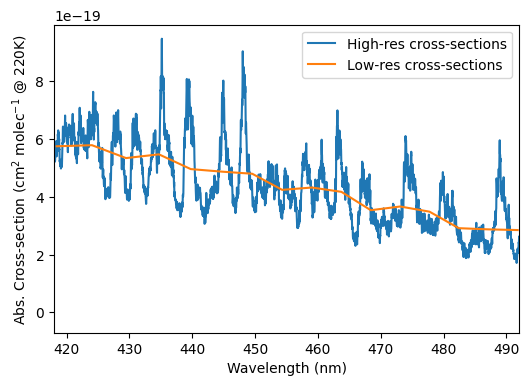

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(no2_cross_sections["vacuum_wavelength_nm"], no2_cross_sections["cross_section_cm^2/molecule_@220K"], label="High-res cross-sections")
ax.plot(enmap_vnir_spectral_bands_fitting_window["wavelength_nm"], no2_cross_sections_conv_fitting_window, label="Low-res cross-sections")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Abs. Cross-section (cm$^2$ molec$^{-1}$ @ 220K)")
ax.set_xlim([wav_min, wav_max])
ax.legend();

### Load EnMAP data

In [13]:
# File path
vnir_dir = "dims_op_oc_oc-en_702667121_1/ENMAP.HSI.L1C/ENMAP01-____L1C-DT0000027893_20230715T080658Z_001_V010502_20250815T105602Z"
vnir_path = os.path.join(vnir_dir, "ENMAP01-____L1C-DT0000027893_20230715T080658Z_001_V010502_20250815T105602Z-SPECTRAL_IMAGE.TIF")
meta_path = os.path.join(vnir_dir, "ENMAP01-____L1C-DT0000027893_20230715T080658Z_001_V010502_20250815T105602Z-METADATA.XML")

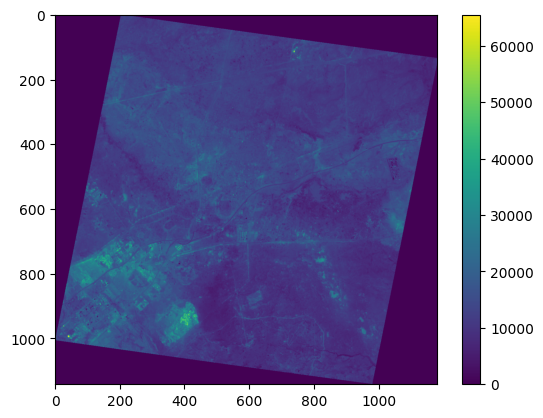

In [14]:
# Plot band 1
ds = rasterio.open(vnir_path)
band1 = ds.read(1)
plt.imshow(band1)
plt.colorbar();

In [15]:
# --- parse per-band gains/offsets from metadata ---
tree = etree.parse(meta_path)
# bandCharacterisation lists bands IN THE SAME ORDER as the spectral image
bands = tree.xpath("//bandCharacterisation/bandID")
gain = np.array([float(b.findtext("GainOfBand")) for b in bands])
offset = np.array([float(b.findtext("OffsetOfBand")) for b in bands])

In [16]:
# Build data cube for spectral fitting window
with rasterio.open(vnir_path) as ds:
    # Print band numbers in fitting window
    desired_bands = enmap_vnir_spectral_bands_fitting_window["band"].values
    print("Desired bands:", desired_bands)

    # Read bands into xarray DataArray
    data = []
    for k in desired_bands:
        arr = ds.read(int(k)).astype(float)
        arr[arr==0] = np.nan
        arr = gain[k] * arr + offset[k] # scale by gain and offset
        data.append(arr[np.newaxis, ...])
    cube = np.concatenate(data, axis=0)  # (nband, ny, nx)
    transform = ds.transform
    crs = ds.crs

# Bin spatially for SNR if requested
if bin_size > 1:
    def bin2d(a, by, bx):
        ny, nx = a.shape
        ny2 = ny // by
        nx2 = nx // bx
        a = a[:ny2*by, :nx2*bx]
        a = a.reshape(ny2, by, nx2, bx).mean(axis=(1,3))
        return a
    cube_b = np.stack([bin2d(cube[i], bin_size, bin_size) for i in range(cube.shape[0])], axis=0)
    # Update geotransform
    transform_b = Affine(transform.a * bin_size, transform.b, transform.c,
                         transform.d, transform.e * bin_size, transform.f)
    ENMAP = {
        "radiance": cube_b,               # (nband, nyb, nxb)
        "wavelength_nm": enmap_vnir_spectral_bands_fitting_window['wavelength_nm'].to_numpy(),
        "fwhm_nm": enmap_vnir_spectral_bands_fitting_window['fwhm_nm'].to_numpy(),
        "transform": transform_b,
        "crs": crs
    }
else:
    ENMAP = {
        "radiance": cube,
        "wavelength_nm": enmap_vnir_spectral_bands_fitting_window['wavelength_nm'].to_numpy(),
        "fwhm_nm": enmap_vnir_spectral_bands_fitting_window['fwhm_nm'].to_numpy(),
        "transform": transform,
        "crs": crs
    }

#ENMAP = {
#        "radiance": cube,
#        "wavelength_nm": enmap_vnir_spectral_bands_fitting_window['wavelength_nm'].to_numpy(),
#        "fwhm_nm": enmap_vnir_spectral_bands_fitting_window['fwhm_nm'].to_numpy(),
#        "transform": transform,
#        "crs": crs
#        }

Desired bands: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


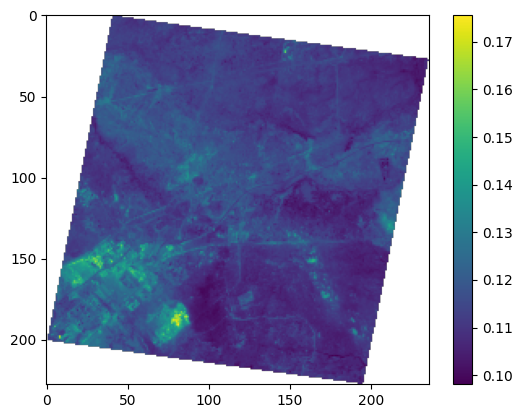

In [17]:
# Plot band 1
plt.imshow(ENMAP["radiance"][0,:,:])
plt.colorbar();

In [18]:
ENMAP['radiance'].shape, ENMAP['wavelength_nm'][:5], ENMAP['fwhm_nm'][:5]

((16, 228, 236),
 array([418.416, 424.043, 429.457, 434.686, 439.758]),
 array([6.99561, 6.6675 , 6.42408, 6.25124, 6.13485]))

### Create reference spectrum

Try simple approach using an upwind region of the image as reference

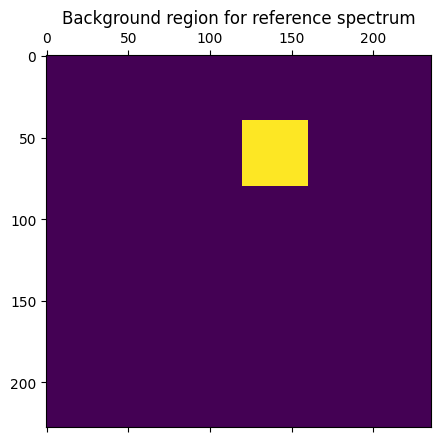

In [19]:
background_mask = np.zeros_like(ENMAP["radiance"][0,:,:])
row1 = int(200/bin_size); row2 = int(400/bin_size)
col1 = int(600/bin_size); col2 = int(800/bin_size)
background_mask[row1:row2, col1:col2] = 1
plt.matshow(background_mask)
plt.title("Background region for reference spectrum");

In [20]:
def compute_reference_spectrum(enmap):
    rad = enmap['radiance']  # (nband, ny, nx)
    ref_spec = rad[:, row1:row2, col1:col2].mean(axis=1).mean(axis=1)  # average over selected pixels
    return ref_spec

ref_spec = compute_reference_spectrum(ENMAP)
ref_spec.shape


(16,)

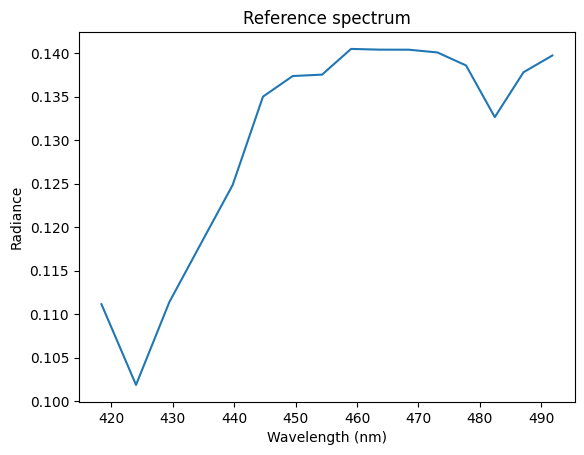

In [21]:
plt.plot(ENMAP["wavelength_nm"], ref_spec)
plt.title("Reference spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance");

### Build the DOAS design matrix

We fit the differential optical depth:

$D(\lambda) = \ln\frac{I_{ref}(\lambda)}{I(\lambda)} = \sum_k a_k\,\sigma_k^{*}(\lambda) + P_m(\lambda) + C_{ring}\,R(\lambda) + \varepsilon $


where $\sigma_k^{*}$ are SRF‑convolved cross‑sections, $P_m$ is a degree‑`poly_degree` polynomial, and $R$ is the Ring pseudo‑absorber.

In [22]:
RING = None

def build_design_matrix(enmap, xs_conv, include_ring=False, include_inverse_spectrum=False, jj=None, ii=None, fit_shift=False, fit_stretch=False, poly_degree=polydeg):
    wav = enmap['wavelength_nm']/1e3
    # Stack species columns
    cols = []
    names = []
    #for name, v in ["NO2", xs_conv]:
    #    cols.append(v)
    #    names.append(name)
    cols.append(xs_conv*1e19)
    names.append("NO2")

    if include_ring:
        cols.append(RING if RING is not None else np.zeros_like(wav))
        names.append('RING')

    # Polynomial baseline
    Xp = np.vstack([wav**i for i in range(poly_degree+1)]).T  # (nband, poly_degree+1)
    for i in range(poly_degree+1):
        cols.append(Xp[:, i])
        names.append(f'poly_{i}')

    if include_inverse_spectrum:
        cols.append(1/enmap["radiance"][:,jj,ii])
        names.append("inverse_spectrum")

    A = np.vstack(cols).T  # (nband, n_par)

    # # Linearized shift/stretch via derivatives (apply to *structured* columns only, not to pure polynomials)
    # shift_cols = []
    # shift_names = []
    # if fit_shift or fit_stretch:
    #     # Derivatives for species + ring (exclude polynomials)
    #     A_struct = np.vstack([xs_conv[n] for n in xs_conv] + ([RING] if (RING is not None and include_ring) else [])).T
    #     dA = derivative_columns(A_struct, wav)
    #     if fit_shift:
    #         shift_cols.append(dA)            # *Δλ
    #         shift_names.extend([f'd_{n}/dlambda' for n in list(xs_conv.keys()) + (['RING'] if (RING is not None and include_ring) else [])])
    #     if fit_stretch:
    #         # simple stretch proxy: (λ-λ0) * derivative
    #         lam0 = 0.5*(wav.min()+wav.max())
    #         shift_cols.append((wav - lam0)[:, None] * dA)  # *Δq
    #         shift_names.extend([f'stretch_{n}' for n in list(xs_conv.keys()) + (['RING'] if (RING is not None and include_ring) else [])])

    # if shift_cols:
    #     S = np.hstack(shift_cols)  # (nband, n_shift)
    #     A = np.hstack([A, S])
    #     names.extend(shift_names)

    return A, names

A, names = build_design_matrix(
    ENMAP, enmap_vnir_spectral_bands_fitting_window["no2_cross_section(cm2/molec)"].values,
)
len(names), names


(5, ['NO2', 'poly_0', 'poly_1', 'poly_2', 'poly_3'])

In [23]:
A

array([[5.74577179, 1.        , 0.418416  , 0.17507195, 0.0732529 ],
       [5.78321354, 1.        , 0.424043  , 0.17981247, 0.07624822],
       [5.3376343 , 1.        , 0.429457  , 0.18443331, 0.07920618],
       [5.4670786 , 1.        , 0.434686  , 0.18895192, 0.08213475],
       [4.95678516, 1.        , 0.439758  , 0.1933871 , 0.08504352],
       [4.86862435, 1.        , 0.444699  , 0.1977572 , 0.08794243],
       [4.79591122, 1.        , 0.449539  , 0.20208531, 0.09084523],
       [4.23901465, 1.        , 0.454306  , 0.20639394, 0.09376601],
       [4.31937785, 1.        , 0.459031  , 0.21070946, 0.09672217],
       [4.17011721, 1.        , 0.46373   , 0.21504551, 0.09972306],
       [3.53502739, 1.        , 0.468411  , 0.21940886, 0.10277353],
       [3.66309526, 1.        , 0.47308   , 0.22380469, 0.10587752],
       [3.48492267, 1.        , 0.477744  , 0.22823933, 0.10903997],
       [2.91355709, 1.        , 0.482411  , 0.23272037, 0.11226687],
       [2.87267705, 1.        , 0.

In [24]:
for col in range(2, A.shape[1]):
    mu = np.mean(A[:, col])
    sigma = np.std(A[:, col])
    A[:, col] = (A[:, col] - mu) / sigma

In [25]:
A

array([[ 5.74577179,  1.        , -1.69111683, -1.6478309 , -1.60511672],
       [ 5.78321354,  1.        , -1.43883998, -1.41455028, -1.38981774],
       [ 5.3376343 ,  1.        , -1.19611262, -1.18715851, -1.17720358],
       [ 5.4670786 ,  1.        , -0.96167941, -0.96479822, -0.96670158],
       [ 4.95678516,  1.        , -0.73428502, -0.74654321, -0.75762318],
       [ 4.86862435,  1.        , -0.5127638 , -0.53149068, -0.54925381],
       [ 4.79591122,  1.        , -0.29577074, -0.31850449, -0.34060453],
       [ 4.23901465,  1.        , -0.0820505 , -0.10647704, -0.13066309],
       [ 4.31937785,  1.        ,  0.12978673,  0.10588937,  0.08182218],
       [ 4.17011721,  1.        ,  0.34045831,  0.3192664 ,  0.29752147],
       [ 3.53502739,  1.        ,  0.55032288,  0.53398675,  0.51678509],
       [ 3.66309526,  1.        ,  0.75964945,  0.75030493,  0.73989601],
       [ 3.48492267,  1.        ,  0.96875186,  0.96853352,  0.96720853],
       [ 2.91355709,  1.        ,  1.1

# DOAS fit

In [26]:
def doas_fit_pixel(I_ref, I_meas, A, weight=None):
    # Differential optical depth
    #D = np.log(np.clip(I_ref, 1e-12, None)) - np.log(np.clip(I_meas, 1e-12, None))
    #D = np.log(np.clip(I_ref/1000, 1e-12, None) / np.clip(I_meas/1000, 1e-12, None))
    D = np.log(I_ref / I_meas)
    if weight is None:
        W = np.eye(len(D))
    else:
        w = np.clip(weight, 1e-12, None)
        W = np.diag(w)
    # Solve normal equations (A^T W A) x = A^T W D
    AtW = A.T @ W
    N = AtW @ A
    y = AtW @ D
    x = linalg.lstsq(N, y)[0]
    # Residuals & covariance estimate
    D_fit = A @ x
    r = D - D_fit
    dof = max(len(D) - A.shape[1], 1)
    s2 = (r @ r) / dof
    cov = s2 * linalg.pinv(N)
    return x, cov, r, s2

def run_doas_scene(enmap, A, names, ref_spec):
    rad = enmap['radiance']  # (nband, ny, nx)
    nband, ny, nx = rad.shape
    # Optional weights: uniform for now
    #weight = None if config['use_uniform_weights'] else np.ones(nband)

    # Index of NO2 columns (both temperatures if present)
    no2_cols = [i for i, n in enumerate(names) if n.startswith('NO2')]

    dscd = np.full((ny, nx), np.nan, dtype=float)
    dscd_err = np.full((ny, nx), np.nan, dtype=float)
    rms = np.full((ny, nx), np.nan, dtype=float)

    for j in range(ny):
        row = rad[:, j, :]  # (nband, nx)
        for i in range(nx):
            I_meas = row[:, i]
            if not np.isfinite(I_meas).all():
                continue
            try:
                #include_inverse_spectrum = False
                #if include_inverse_spectrum:
                #    A, names = build_design_matrix(
                #                                   enmap, enmap_vnir_spectral_bands_fitting_window["no2_cross_section(cm2/molec)"].values, include_inverse_spectrum=True, jj=j, ii=i,
                #                                  )
                x, cov, r, s2 = doas_fit_pixel(ref_spec, I_meas, A)#, weight=weight)
                # Sum NO2 components if multiple temps are included
                dscd_val = np.nansum([x[k] for k in no2_cols])
                # Error as sqrt of sum of variances (approx), ignoring covariance between NO2 temps
                dscd_var = np.nansum([cov[k, k] for k in no2_cols])
                dscd[j, i] = dscd_val
                dscd_err[j, i] = np.sqrt(max(dscd_var, 0))
                rms[j, i] = np.sqrt(np.mean(r**2))
            except Exception as e:
                continue

    out = {
        "dSCD": dscd,
        "dSCD_err": dscd_err,
        "rms": rms,
        "names": names
    }
    return out

['NO2', 'poly_0', 'poly_1', 'poly_2', 'poly_3']
[ 2.12369214e-03  2.88841190e-02  1.28924347e+00 -2.53867317e+00
  1.24844090e+00]


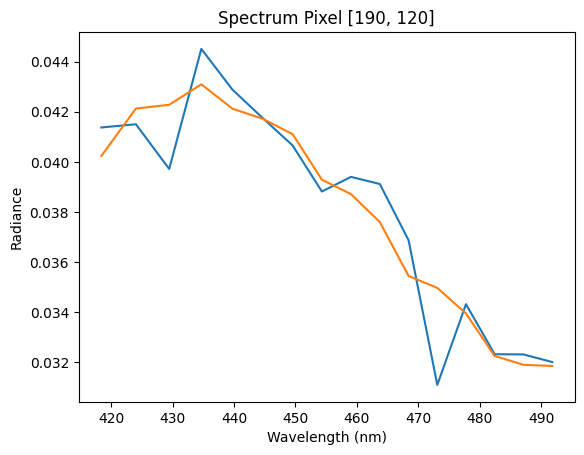

In [27]:
ii = int(950/bin_size)
jj = int(600/bin_size)
I_ref_ = ref_spec.copy()
I_meas_ = ENMAP["radiance"][:,ii,jj]
fit_output = doas_fit_pixel(I_ref_, I_meas_, A)
print(names)
print(fit_output[0])
pred = A@fit_output[0]
plt.plot(ENMAP["wavelength_nm"], np.log(I_ref_/I_meas_))
plt.plot(ENMAP["wavelength_nm"], pred)
#plt.plot(ENMAP["wavelength_nm"], ref_spec)
plt.title(f"Spectrum Pixel [{ii}, {jj}]")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance");

In [28]:
DOAS = run_doas_scene(ENMAP, A, names, ref_spec)
for k, v in DOAS.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)
    else:
        print(k, type(v))

dSCD (228, 236)
dSCD_err (228, 236)
rms (228, 236)
names <class 'list'>


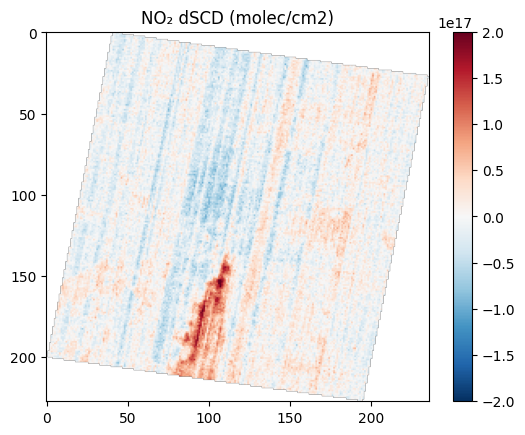

In [29]:
def imshow_quick(a, title, vmin=None, vmax=None):
    plt.figure()
    plt.imshow(a, vmin=vmin, vmax=vmax, origin='upper', cmap="RdBu_r") # vmin=-2e-39, vmax=2e-39,
    plt.title(title)
    plt.colorbar()
    plt.show()

imshow_quick(DOAS['dSCD']*1e19, 'NO₂ dSCD (molec/cm2)', vmin=-2e17, vmax=2e17)
#imshow_quick(DOAS['dSCD_err'], 'NO₂ dSCD error (arb.)')
#imshow_quick(DOAS['rms'], 'Fit RMS (optical depth)')

# DOAS fit with reference spectrum by detector row

In [30]:
# ---------- 0) (Optional) estimate stripe angle from data ----------
def estimate_stripe_angle(continuum, mask=None, angles=np.linspace(-80, 80, 321)):
    """
    Estimate stripe orientation by scanning angles and maximizing variance
    across oblique-row means of a continuum image (e.g., mean radiance in the window).
    """
    ny, nx = continuum.shape
    if mask is None:
        mask = np.isfinite(continuum)
    # Subsample to speed up, without changing the result materially
    step = max(1, min(ny, nx) // 512)
    I, J = np.meshgrid(np.arange(nx), np.arange(ny))
    I, J = I[::step, ::step], J[::step, ::step]
    C = continuum[::step, ::step]
    M = mask[::step, ::step]

    best_theta, best_score = 0.0, -np.inf
    for th in angles:
        t = np.deg2rad(th)
        rho = -np.sin(t)*I + np.cos(t)*J
        rho = rho[M]
        vals = C[M]
        # Quantize rho to integer bins and compute per-row means
        rho0 = rho - rho.min()
        idx = np.round(rho0).astype(np.int32)
        sums = np.bincount(idx, weights=vals, minlength=idx.max()+1)
        cnts = np.bincount(idx, minlength=idx.max()+1)
        means = sums / np.maximum(cnts, 1)
        score = np.var(means)  # stripes -> larger variance across rows
        if score > best_score:
            best_score, best_theta = score, th
    return float(best_theta)


# ---------- 1) Map pixels to oblique rows (no resampling) ----------
def build_oblique_row_index(ny, nx, theta_deg):
    """
    Return integer oblique-row index s[j,i] for each pixel (j,i).
    Pixels with the same s lie on the same oblique detector row.
    """
    I, J = np.meshgrid(np.arange(nx), np.arange(ny))
    t = np.deg2rad(theta_deg)
    rho = -np.sin(t)*I + np.cos(t)*J
    rho -= rho.min()                 # shift to non-negative
    s = np.round(rho).astype(np.int32)
    return s  # shape (ny, nx), values in [0, S-1]


# ---------- 2) Precompute sums/counts per oblique row ----------
def precompute_oblique_row_stats(radiance, s_index, eligible_mask=None):
    """
    radiance: (nband, ny, nx)
    s_index: (ny, nx) integer oblique row index from build_oblique_row_index
    eligible_mask: (ny, nx) boolean (True pixels contribute to reference pool)
    Returns dict with per-row sums and counts.
    """
    nband, ny, nx = radiance.shape
    S = int(s_index.max()) + 1

    if eligible_mask is None:
        eligible_mask = np.isfinite(radiance).all(axis=0)  # valid across all bands

    # Flatten indices and mask
    idx_flat = s_index[eligible_mask].ravel()
    cnt_per_row = np.bincount(idx_flat, minlength=S).astype(np.int32)

    # Per-band sums per row (vectorized via bincount)
    sum_per_row = np.zeros((nband, S), dtype=np.float64)
    for b in range(nband):
        w = radiance[b][eligible_mask].ravel()
        sum_per_row[b] = np.bincount(idx_flat, weights=w, minlength=S)

    return {
        "sum_per_row": sum_per_row,     # (nband, S)
        "cnt_per_row": cnt_per_row,     # (S,)
        "s_index": s_index,              # (ny, nx)
        "eligible_mask": eligible_mask   # (ny, nx)
    }


# ---------- 3) Get the oblique-row reference spectrum for a pixel ----------
def oblique_row_reference_for_pixel(stats, radiance, j, i, exclude_self=True):
    """
    Return I_ref(λ; j,i) as the average over the same oblique row (minus self if requested).
    Handles NODATA/NaNs via the eligible_mask used in precompute_oblique_row_stats.
    """
    s = stats["s_index"][j, i]
    sum_s = stats["sum_per_row"][:, s]          # (nband,)
    cnt_s = stats["cnt_per_row"][s].astype(int)

    # If this pixel was part of the eligible pool, optionally remove it
    if exclude_self and stats["eligible_mask"][j, i]:
        ref = (sum_s - radiance[:, j, i]) / max(cnt_s - 1, 1)
    else:
        ref = sum_s / max(cnt_s, 1)
    return ref


# ---------- 4) DOAS loop using oblique-row references ----------
def run_doas_scene_oblique_rowref(enmap, A, names, theta_deg, plume_mask=None):
    rad = enmap['radiance']  # (nband, ny, nx)
    nband, ny, nx = rad.shape
    # Optional weights: uniform for now
    #weight = None if config['use_uniform_weights'] else np.ones(nband)

    # 1) Oblique row index
    s_index = build_oblique_row_index(ny, nx, theta_deg)
    # 2) Precompute per-row sums/counts
    stats = precompute_oblique_row_stats(rad, s_index, eligible_mask=plume_mask)

    # Index of NO2 columns (both temperatures if present)
    no2_cols = [i for i, n in enumerate(names) if n.startswith('NO2')]

    dscd = np.full((ny, nx), np.nan, dtype=float)
    dscd_err = np.full((ny, nx), np.nan, dtype=float)
    rms = np.full((ny, nx), np.nan, dtype=float)

    for j in range(ny):
        row = rad[:, j, :]  # (nband, nx)
        for i in range(nx):
            I_meas = row[:, i]
            ref_spec = oblique_row_reference_for_pixel(stats, rad, j, i)
            if not np.isfinite(I_meas).all():
                continue
            try:
                x, cov, r, s2 = doas_fit_pixel(ref_spec, I_meas, A)#, weight=weight)
                # Sum NO2 components if multiple temps are included
                dscd_val = np.nansum([x[k] for k in no2_cols])
                # Error as sqrt of sum of variances (approx), ignoring covariance between NO2 temps
                dscd_var = np.nansum([cov[k, k] for k in no2_cols])
                dscd[j, i] = dscd_val
                dscd_err[j, i] = np.sqrt(max(dscd_var, 0))
                rms[j, i] = np.sqrt(np.mean(r**2))
            except Exception as e:
                continue

    out = {
        "dSCD": dscd,
        "dSCD_err": dscd_err,
        "rms": rms,
        "names": names
    }
    return out

In [31]:
theta_deg = estimate_stripe_angle(np.isnan(ENMAP["radiance"][0,:,:]))
print(theta_deg)
DOAS0 = run_doas_scene_oblique_rowref(ENMAP, A, names, theta_deg)
for k, v in DOAS0.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)
    else:
        print(k, type(v))

-78.5
dSCD (228, 236)
dSCD_err (228, 236)
rms (228, 236)
names <class 'list'>


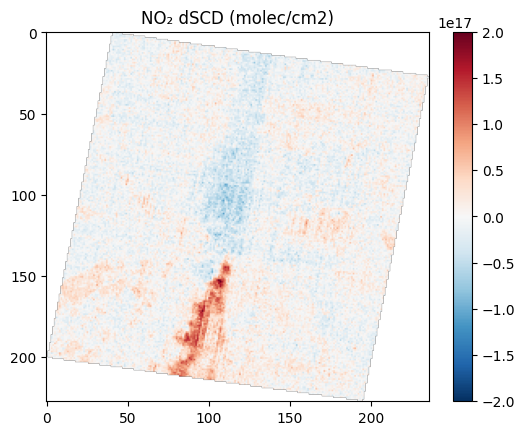

In [32]:
imshow_quick(DOAS0['dSCD']*1e19, 'NO₂ dSCD (molec/cm2)', vmin=-2e17, vmax=2e17)
#imshow_quick(gaussian_filter(DOAS0['dSCD']*1e19, sigma=0.5), 'NO₂ dSCD (molec/cm2)', vmin=-2e17, vmax=2e17)

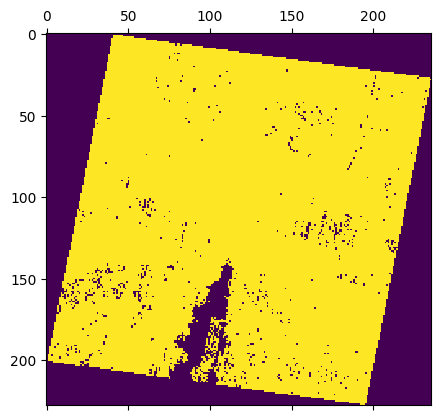

In [33]:
plume_mask = [DOAS0['dSCD'] < np.nanpercentile(DOAS0['dSCD'], 95)][0]
plt.matshow(plume_mask)

In [34]:
DOAS = run_doas_scene_oblique_rowref(ENMAP, A, names, theta_deg, plume_mask)
for k, v in DOAS.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)
    else:
        print(k, type(v))

dSCD (228, 236)
dSCD_err (228, 236)
rms (228, 236)
names <class 'list'>


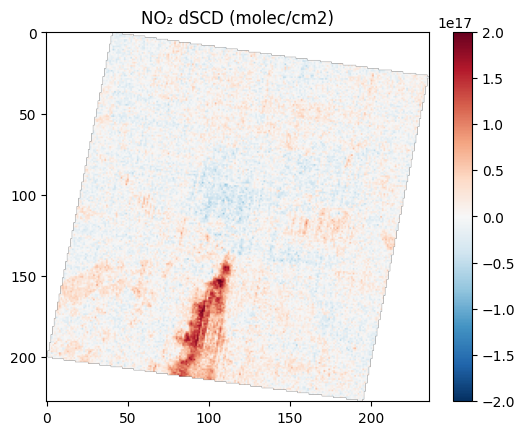

In [35]:
imshow_quick(DOAS['dSCD']*1e19, 'NO₂ dSCD (molec/cm2)', vmin=-2e17, vmax=2e17)

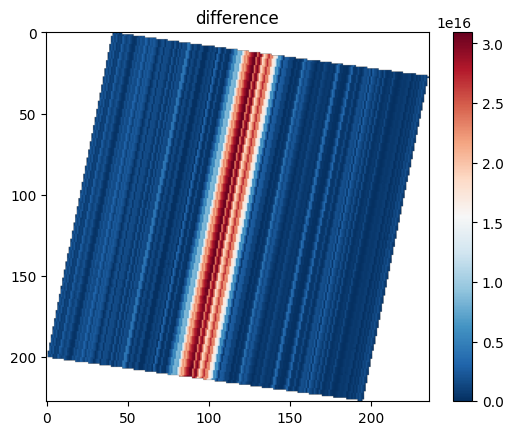

In [36]:
imshow_quick(DOAS['dSCD']*1e19 - DOAS0['dSCD']*1e19, "difference")

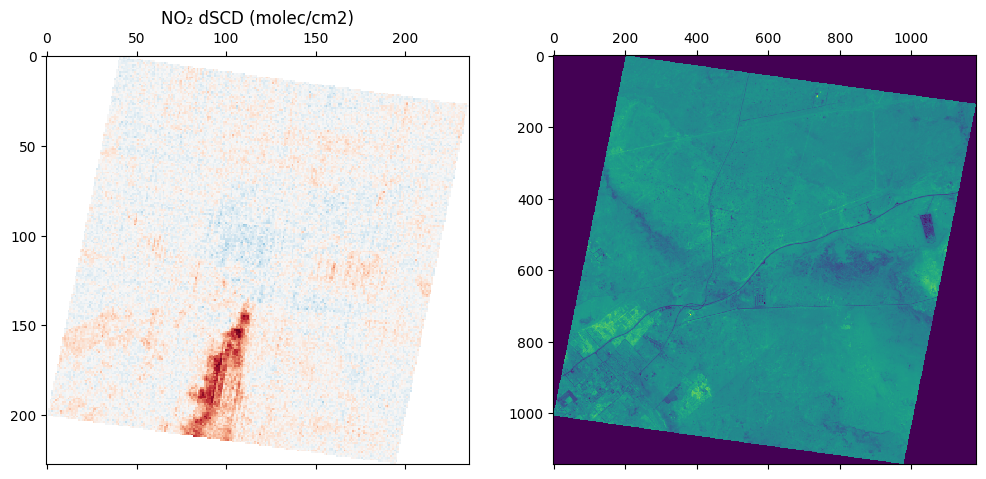

In [37]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,6))
ax1.matshow(DOAS['dSCD']*1e19, vmin=-2e17, vmax=2e17, origin='upper', cmap="RdBu_r") # vmin=-2e-39, vmax=2e-39,
ax1.set_title("NO₂ dSCD (molec/cm2)")

ds = rasterio.open(vnir_path)
ax2.matshow(ds.read(74))

-----